In [45]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import skfuzzy as fuzz
from sklearn.model_selection import train_test_split

# ============================
# FIX RANDOMNESS HERE
# ============================
seed = 42
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
# ============================

In [46]:
# ---------------------------
# 1) Prepare Mackey-Glass Dataset
# ---------------------------
beta = 0.2
tau = 17.0
gamma = 0.1
n = 10.0
dt = 0.1

delay = int(tau / dt)
init_value = 1.2
T = 1000.0
num_steps = int(T / dt)

x = np.zeros(num_steps)
x[:delay] = init_value
time = np.arange(num_steps) * dt

for t in range(delay, num_steps - 1):
    feedback = (beta * x[t - delay]) / (1 + (x[t - delay]) ** n)
    x[t + 1] = x[t] + dt * (feedback - gamma * x[t])

time_pos = time[delay:]
x_pos = x[delay:]

lags = [24, 18, 12, 6]
max_lag = max(lags)
X, y = [], []
for t in range(max_lag, len(x_pos)):
    X.append([x_pos[t - lag] for lag in lags])
    y.append(x_pos[t])

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32).reshape(-1, 1)

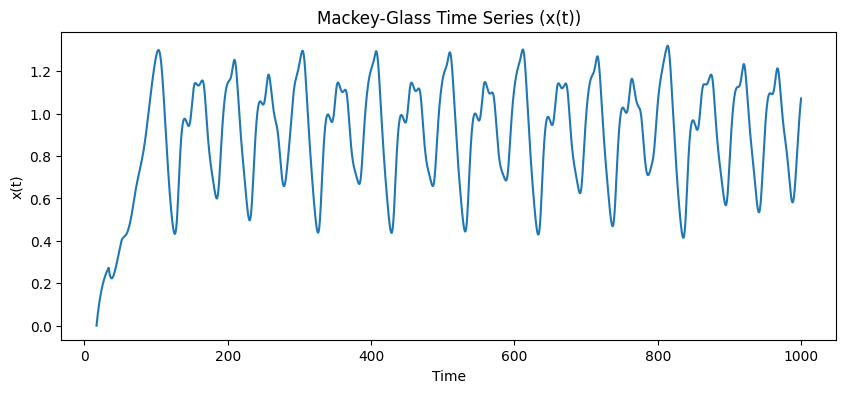

In [54]:
#plot

plt.figure(figsize=(10, 4))
plt.plot(time_pos, x_pos)
plt.title("Mackey-Glass Time Series (x(t))")
plt.xlabel("Time")
plt.ylabel("x(t)")

plt.show()

In [48]:
# ---------------------------
# 2) Fuzzy C-Means for Initialization
# ---------------------------
def fcm_initialize(X, K, m=2.0):
    """
    X: numpy array shape (N, n_inputs)
    K: number of clusters / rules
    Returns:
        centers: (K, n_inputs)
        spreads: (K, n_inputs)
    """
    X_t = X.T  # (n_inputs, N)
    cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
        X_t,
        c=K,
        m=m,
        error=1e-5,
        maxiter=2000,
        init=None,
    )
    N = X.shape[0]

    spreads = []
    for k in range(K):
        weights = u[k].reshape(N, 1)   # (N,1)
        diff = X - cntr[k]             # (N, n_inputs)
        denom = np.sum(weights) + 1e-12
        var = np.sum(weights * (diff ** 2), axis=0) / denom
        spreads.append(np.sqrt(var))
    spreads = np.array(spreads)
    spreads = np.clip(spreads, 1e-3, None)
    return np.array(cntr), spreads


In [49]:
# ---------------------------
# 3) Train/Test Split (time-series split: no shuffle)
# ---------------------------

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

time_full = time_pos[max_lag:]
time_train = time_full[: len(X_train)]
time_test  = time_full[len(X_train):]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_tensor = torch.from_numpy(X_train).to(device)
y_train_tensor = torch.from_numpy(y_train).to(device)
X_test_tensor = torch.from_numpy(X_test).to(device)
y_test_tensor = torch.from_numpy(y_test).to(device)

n_inputs = X.shape[1]
K = 9

# ---------------------------
# 4) FCM Initialization
# ---------------------------
centers_init, spreads_init = fcm_initialize(X_train, K)

## 1. GaussianSigmoidMF Layer

* **Inputs**: `x` (batch, $n_\text{inputs}$)
* **Parameters**:

  * `centers` $m_j^i$: Gaussian centers (initialized via FCM)
  * `spreads` $\sigma_j^i$: Gaussian spreads (softplus for positivity)
  * `C` (optional trainable): controls blending of Gaussian and Sigmoid
* **Steps**:

  1. Compute **Gaussian MF**:
     $$\mu_\text{gauss} = \exp\Big(-\frac{(x - m)^2}{2 \sigma^2}\Big)$$
  2. Compute **Sigmoid MF**:
     $$\mu_\text{sig} = \frac{1}{1 + \exp\Big(-\frac{x - m}{\sigma}\Big)}$$
  3. Blend:
     $$\mu^+ = s \cdot \mu_\text{gauss} + (1 - s) \cdot \mu_\text{sig}, \quad s = \text{sigmoid}(C)$$
  4. Combine across inputs using **product (AND)**:
     $$w^i = \prod_j \mu_j^{i+} \quad \text{(firing strength of rule $i$)}$$


In [57]:
# ---------------------------
# 5) New MF layer: Gaussian + Sigmoid blend
#    Modes for s: "C" or "alpha_beta"
# ---------------------------

class GaussianSigmoidMF(nn.Module):
    def __init__(self, centers_init, spreads_init, eps_s=1e-6):
        """
        centers_init: (K, n_inputs)
        spreads_init: (K, n_inputs)
        s_mode: "C" or "alpha_beta"
           - "C": learn C_j^i and s = sigmoid(C)
           - "alpha_beta": learn alpha and beta and s = alpha^2 / (alpha^2 + beta^2 + eps)
        """
        super().__init__()
        self.K = centers_init.shape[0]
        self.n_inputs = centers_init.shape[1]
        self.eps_s = eps_s

        # m_j^i: centers
        self.centers = nn.Parameter(torch.tensor(centers_init, dtype=torch.float32))  # (K, n_inputs)

        # sigma_j^i: spreads - store as raw parameter but use softplus to ensure positivity
        self.spreads = nn.Parameter(torch.tensor(spreads_init, dtype=torch.float32))  # (K, n_inputs)

        # learn C per (K, n_inputs)
        # initialize to 0 so s = 0.5 initially
        self.C = nn.Parameter(torch.ones(self.K, self.n_inputs, dtype=torch.float32) * 5.0)

    def forward(self, x):
        """
        x: (batch, n_inputs)
        returns firing strengths: (batch, K) derived from product of blended MFs across inputs
        """
        batch = x.shape[0]

        x_exp = x.unsqueeze(1)  # (batch, 1, n_inputs)
        c_exp = self.centers.unsqueeze(0)  # (1, K, n_inputs)
        # positive spreads via softplus
        s_raw = torch.nn.functional.softplus(self.spreads).unsqueeze(0)  # (1, K, n_inputs)
        s_raw = torch.clamp(s_raw, min=1e-6)

        # Gaussian MF: exp(-((x-c)^2) / (2 * sigma^2))
        mu_gauss = torch.exp(-((x_exp - c_exp) ** 2) / (2.0 * (s_raw ** 2) + 1e-12))  # (batch, K, n_inputs)

        # Sigmoid-like MF: sigmoid( - (1/sigma) * (x - m) )
        # as user wrote: 1/(1 + exp(-1/sigma * (x - m)))
        # compute exponent: - (1/sigma) * (x - m)  -> pass to torch.sigmoid
        mu_sigexponent = - (1.0 / (s_raw + 1e-12)) * (x_exp - c_exp)  # (batch, K, n_inputs)
        mu_sig = torch.sigmoid(mu_sigexponent)  # (batch, K, n_inputs)

        C_exp = self.C.unsqueeze(0)  # (1, K, n_inputs)
        s_mix = torch.sigmoid(C_exp)  # (1, K, n_inputs) in (0,1)

        # Broadcast s_mix to (batch, K, n_inputs)
        s_mix_b = s_mix.expand(batch, -1, -1)

        # blended MF
        mu_plus = s_mix_b * mu_gauss + (1.0 - s_mix_b) * mu_sig  # (batch, K, n_inputs)

        # combine across inputs using product (AND)
        firing = torch.prod(mu_plus, dim=2)  # (batch, K)
        return firing

## 2. ANFIS_BlendMF Model

* **Firing strengths**: $w$ from MF layer
* **Normalization**:
  $$\hat{w}^i = \frac{w^i}{\sum_i w^i} \quad \text{(ensures weighted sum)}$$
* **Consequents**: Linear Takagi–Sugeno rules
  $$y^i_\text{rule} = a_0^i + \sum_j a_j^i x_j$$
* **Final output**: Weighted sum of rule outputs
  $$y_\text{pred} = \sum_i \hat{w}^i , y^i_\text{rule}$$

In [58]:
# ---------------------------
# 6) ANFIS Model With New MF
# ---------------------------

class ANFIS_BlendMF(nn.Module):
    def __init__(self, centers_init, spreads_init):
        super().__init__()
        self.K = centers_init.shape[0]
        self.n_inputs = centers_init.shape[1]

        self.mf_layer = GaussianSigmoidMF(centers_init, spreads_init)

        # consequents: a0 and a_j for each rule
        # shape: (K, n_inputs + 1) where last column is bias a0^i
        self.consequents = nn.Parameter(torch.randn(self.K, self.n_inputs + 1, dtype=torch.float32) * 0.1)

    def forward(self, x):
        # x: (batch, n_inputs)
        w = self.mf_layer(x)  # (batch, K)
        w_sum = torch.sum(w, dim=1, keepdim=True) + 1e-8
        w_norm = w / w_sum

        # compute rule outputs y_r = a0 + sum_j a_j * x_j
        x_exp = x.unsqueeze(1).expand(-1, self.K, -1)  # (batch, K, n_inputs)
        cons_linear = self.consequents[:, :-1].unsqueeze(0)  # (1, K, n_inputs)
        linear_part = torch.sum(x_exp * cons_linear, dim=2)  # (batch, K)
        bias = self.consequents[:, -1].unsqueeze(0)  # (1, K)
        y_r = linear_part + bias  # (batch, K)

        y_pred = torch.sum(w_norm * y_r, dim=1, keepdim=True)  # (batch, 1)
        return y_pred

Epoch 1/2000  Train MSE: 6.156108e-01  Test MSE: 6.505262e-01
Epoch 200/2000  Train MSE: 1.143488e-02  Test MSE: 1.215637e-02
Epoch 400/2000  Train MSE: 2.646184e-03  Test MSE: 2.793044e-03
Epoch 600/2000  Train MSE: 2.507235e-03  Test MSE: 2.655219e-03
Epoch 800/2000  Train MSE: 2.381223e-03  Test MSE: 2.525713e-03
Epoch 1000/2000  Train MSE: 2.248421e-03  Test MSE: 2.390595e-03
Epoch 1200/2000  Train MSE: 2.108755e-03  Test MSE: 2.251398e-03
Epoch 1400/2000  Train MSE: 1.962037e-03  Test MSE: 2.107435e-03
Epoch 1600/2000  Train MSE: 1.806706e-03  Test MSE: 1.955434e-03
Epoch 1800/2000  Train MSE: 1.638630e-03  Test MSE: 1.788408e-03
Epoch 2000/2000  Train MSE: 1.450404e-03  Test MSE: 1.595632e-03

Final results:
Test RMSE: 0.039945364


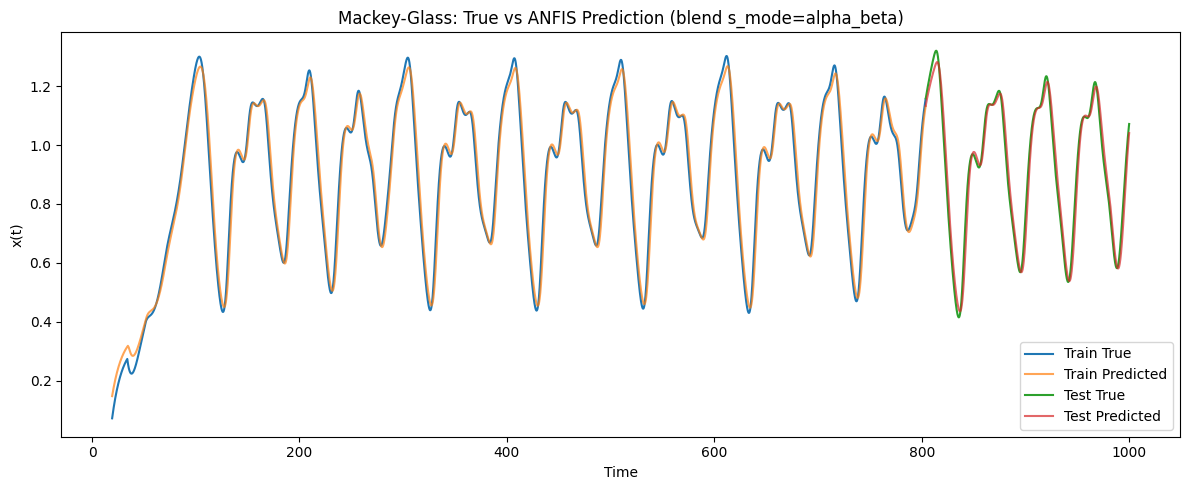

In [59]:
# ---------------------------
# 7) Training
# ---------------------------

model = ANFIS_BlendMF(centers_init, spreads_init).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

n_epochs = 2000
best_loss = float("inf")
best_state = None

for epoch in range(1, n_epochs + 1):
    model.train()
    optimizer.zero_grad()
    y_pred_train = model(X_train_tensor)
    loss = loss_fn(y_pred_train, y_train_tensor)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
    optimizer.step()

    # track best
    if loss.item() < best_loss:
        best_loss = loss.item()
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 200 == 0 or epoch == 1:
        with torch.no_grad():
            model.eval()
            y_tr = model(X_train_tensor)
            y_te = model(X_test_tensor)
            train_mse = loss_fn(y_tr, y_train_tensor).item()
            test_mse  = loss_fn(y_te, y_test_tensor).item()
        print(f"Epoch {epoch}/{n_epochs}  Train MSE: {train_mse:.6e}  Test MSE: {test_mse:.6e}")

# restore best
if best_state is not None:
    model.load_state_dict(best_state)
model.eval()

with torch.no_grad():
    y_pred_train_tensor = model(X_train_tensor)
    y_pred_test_tensor = model(X_test_tensor)

y_pred_train_np = y_pred_train_tensor.cpu().numpy().reshape(-1)
y_pred_test_np  = y_pred_test_tensor.cpu().numpy().reshape(-1)
y_train_np = y_train.reshape(-1)
y_test_np  = y_test.reshape(-1)

test_mse = np.mean((y_test_np - y_pred_test_np) ** 2)
test_rmse = np.sqrt(test_mse)
train_mse = np.mean((y_train_np - y_pred_train_np) ** 2)
train_rmse = np.sqrt(train_mse)

print("\nFinal results:")
print("Test RMSE:", test_rmse)

# ---------------------------
# 8) Plot results
# ---------------------------
plt.figure(figsize=(12, 5))
plt.plot(time_train, y_train_np, label="Train True")
plt.plot(time_train, y_pred_train_np, label="Train Predicted", alpha=0.7)
plt.plot(time_test, y_test_np, label="Test True")
plt.plot(time_test, y_pred_test_np, label="Test Predicted", alpha=0.7)
plt.xlabel("Time")
plt.ylabel("x(t)")
plt.title(f"Mackey-Glass: True vs ANFIS Prediction (blend s_mode={s_mode_choice})")
plt.legend()
plt.tight_layout()
plt.show()
